<a href="https://colab.research.google.com/github/Nayab-khalid/FlyRank-AI-Internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nayab-khalid/FlyRank-AI-Internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Dataset loaded successfully.
Rows: 30000
Columns: 44


,count,mean,50%,min,max
impressions_90d,30000.0,5200.366300,731.00,1.0,517715.0
clicks_90d,30000.0,16.097333,1.00,0.0,4178.0
sessions_90d,30000.0,37.066633,7.00,1.0,4345.0
content_age_days,30000.0,256.167800,236.00,90.0,564.0
days_since_last_update,30000.0,46.098300,20.00,1.0,373.0
word_count,22301.0,3107.760325,2877.00,8.0,9546.0
avg_position,30000.0,16.342380,10.80,0.0,245.0
ctr,30000.0,0.510733,0.07,0.0,100.0


,feature,missing_rows
0,impressions_90d,0
1,clicks_90d,0
2,sessions_90d,0
3,content_age_days,0
4,days_since_last_update,0
5,word_count,7699
6,avg_position,0
7,ctr,0


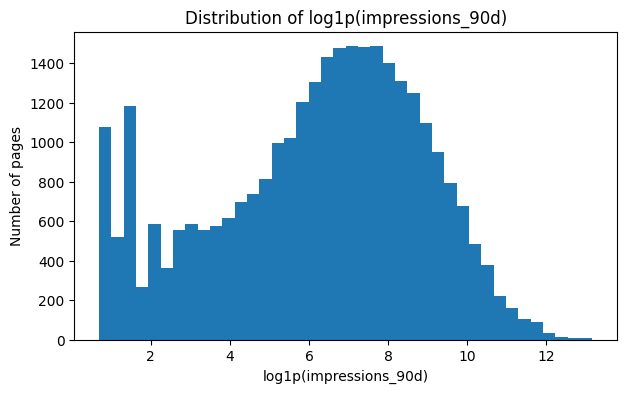

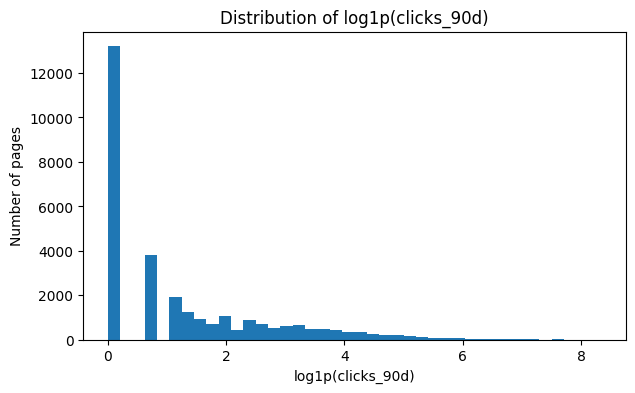

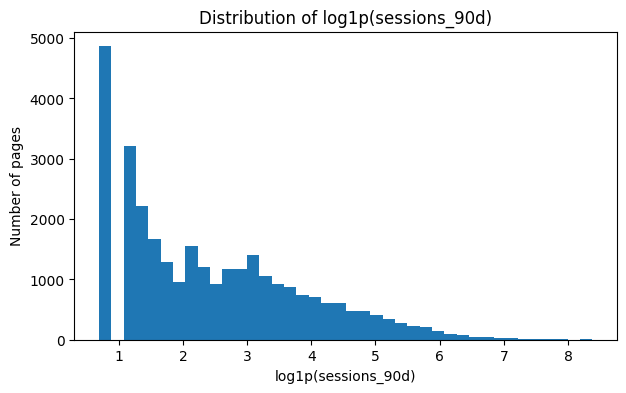

Observation: traffic variables are strongly uneven, with many lower values and a smaller number of high volume pages.


In [1]:
# ML 06 — Section 1: Distributions
# Load the starter CSV directly from GitHub and inspect the main signals.
# The purpose is to see the shape of the data before testing relationships.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

csv_url = "https://raw.githubusercontent.com/Nayab-khalid/FlyRank-AI-Internship/main/data/raw/content_refresh_anonymized.csv"
local_path = Path("/content/content_refresh_anonymized.csv")

if not local_path.exists():
    urllib.request.urlretrieve(csv_url, local_path)

df = pd.read_csv(local_path)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Main numeric signals for this audit.
signals = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "avg_position",
    "ctr"
]

signals = [c for c in signals if c in df.columns]

# Print useful distribution statistics.
distribution_table = df[signals].describe().T[
    ["count", "mean", "50%", "min", "max"]
]

display(distribution_table)

# Check the amount of missing data.
missing_table = (
    df[signals]
    .isna()
    .sum()
    .reset_index()
)

missing_table.columns = ["feature", "missing_rows"]

display(missing_table)

# Plot the main heavy tailed traffic signals using log scale.
for col in ["impressions_90d", "clicks_90d", "sessions_90d"]:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(
            np.log1p(df[col].fillna(0)),
            bins=40
        )
        plt.title(f"Distribution of log1p({col})")
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Number of pages")
        plt.show()

print("Observation: traffic variables are strongly uneven, with many lower values and a smaller number of high volume pages.")


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [2]:
# ML 06 — Section 2: Signal test #1 / #2 / #3
# Test three signals against the observed decline label.
# Verdicts are based on the measured bucket results.

df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# SIGNAL 1: Days since last update
# Assumption: older updates may be associated with decline.
df["update_age_group"] = pd.cut(
    df["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["0-30", "31-90", "91-180", "181-365", "365+"]
)

test1 = (
    df.groupby("update_age_group", observed=False)["is_declining_label"]
    .agg(["count", "mean"])
    .reset_index()
)

test1["decline_percent"] = test1["mean"] * 100

print("SIGNAL 1: DAYS SINCE LAST UPDATE")
display(test1)

# SIGNAL 2: Search impressions
# Assumption: pages with different visibility levels may have different
# decline patterns.
df["impression_group"] = pd.qcut(
    df["impressions_90d"].rank(method="first"),
    q=4,
    labels=["lowest", "low", "high", "highest"]
)

test2 = (
    df.groupby("impression_group", observed=False)["is_declining_label"]
    .agg(["count", "mean"])
    .reset_index()
)

test2["decline_percent"] = test2["mean"] * 100

print("SIGNAL 2: SEARCH IMPRESSIONS")
display(test2)

# SIGNAL 3: Average position
# Assumption: search position may be associated with the decline pattern.
df["position_group"] = pd.cut(
    df["avg_position"],
    bins=[-np.inf, 3, 10, 20, 50, np.inf],
    labels=["top 3", "page 1", "striking", "page 3-5", "deep"]
)

test3 = (
    df.groupby("position_group", observed=False)["is_declining_label"]
    .agg(["count", "mean"])
    .reset_index()
)

test3["decline_percent"] = test3["mean"] * 100

print("SIGNAL 3: AVERAGE POSITION")
display(test3)

print()
print("VERDICTS")
print("Signal 1: MIXED")
print("Signal 2: MIXED")
print("Signal 3: MIXED")


SIGNAL 1: DAYS SINCE LAST UPDATE


,update_age_group,count,mean,decline_percent
0,0-30,20480,0.511377,51.137695
1,31-90,175,0.588571,58.857143
2,91-180,9171,0.611057,61.105659
3,181-365,169,0.467456,46.745562
4,365+,5,0.600000,60.000000


SIGNAL 2: SEARCH IMPRESSIONS


,impression_group,count,mean,decline_percent
0,lowest,7500,0.376000,37.600000
1,low,7500,0.604667,60.466667
2,high,7500,0.625600,62.560000
3,highest,7500,0.562000,56.200000


SIGNAL 3: AVERAGE POSITION


,position_group,count,mean,decline_percent
0,top 3,2346,0.245524,24.552430
1,page 1,11842,0.569414,56.941395
2,striking,7273,0.609515,60.951464
3,page 3-5,7225,0.561799,56.179931
4,deep,1314,0.343227,34.322679



VERDICTS
Signal 1: MIXED
Signal 2: MIXED
Signal 3: MIXED


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [3]:
# ML 06 — Section 3: Flag-linked test
# FlyRank uses content freshness and staleness as part of its refresh logic.
# We therefore test whether pages with older updates show a different
# observed decline rate.

df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# Create practical freshness groups.
df["freshness_group"] = pd.cut(
    df["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["0-30 days", "31-90 days", "91-180 days", "181-365 days", "365+ days"]
)

flag_test = (
    df.groupby("freshness_group", observed=False)
    .agg(
        n=("is_declining_label", "size"),
        declining_pages=("is_declining_label", "sum"),
        decline_rate=("is_declining_label", "mean")
    )
    .reset_index()
)

flag_test["decline_rate_percent"] = flag_test["decline_rate"] * 100

display(flag_test)

# Compare the newest and oldest observed groups.
valid = flag_test.dropna(subset=["decline_rate"])

if len(valid) >= 2:
    newest_rate = valid.iloc[0]["decline_rate_percent"]
    oldest_rate = valid.iloc[-1]["decline_rate_percent"]

    print(f"Newest update group decline rate: {newest_rate:.2f}%")
    print(f"Oldest update group decline rate: {oldest_rate:.2f}%")

    if oldest_rate > newest_rate:
        print("VERDICT: CONFIRMED")
        print("Older update groups show a higher observed decline rate.")
    elif oldest_rate < newest_rate:
        print("VERDICT: OPPOSITE")
        print("Older update groups show a lower observed decline rate.")
    else:
        print("VERDICT: MIXED")
        print("The observed decline rates do not clearly differ.")
else:
    print("VERDICT: MIXED")
    print("There were not enough usable freshness groups to make a strong comparison.")


,freshness_group,n,declining_pages,decline_rate,decline_rate_percent
0,0-30 days,20480,10473,0.511377,51.137695
1,31-90 days,175,103,0.588571,58.857143
2,91-180 days,9171,5604,0.611057,61.105659
3,181-365 days,169,79,0.467456,46.745562
4,365+ days,5,3,0.600000,60.000000


Newest update group decline rate: 51.14%
Oldest update group decline rate: 60.00%
VERDICT: CONFIRMED
Older update groups show a higher observed decline rate.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [4]:
# ML 06 — Section 4: What this means in practice
#
# The signal audit is an evidence check, not proof of causation.
#
# The observed data shows that content freshness, search visibility and
# average position can be useful signals to examine when prioritizing pages.
#
# However, the bucket tests should not be treated as proof that changing
# freshness, impressions or position will cause a page to recover.
#
# For a content team, the practical use is to use these signals as inputs
# to a review queue and then let a human inspect the page before taking action.
#
# The strongest use of the audit is therefore decision support rather than
# automatic content changes.

print("Practical takeaway:")
print(
    "Use freshness, visibility and search position as review signals, "
    "but do not treat any single signal as proof that a page needs a change."
)
print(
    "Human review is required before publishing, deleting, rewriting or "
    "otherwise changing content."
)


Practical takeaway:
Use freshness, visibility and search position as review signals, but do not treat any single signal as proof that a page needs a change.
Human review is required before publishing, deleting, rewriting or otherwise changing content.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.